In [1]:
#imports section
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [3]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [5]:
df.describe() 

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [6]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

## 2.1 Load & Inspect — Summary

- **Rows:** 187,531 | **Columns:** 21
- **Numeric columns:** Index, Price (in rupees), Dimensions, Plot Area
- **Text/categorical columns:** Title, Description, Amount(in rupees), location, Carpet Area, Status, Floor, Transaction, Furnishing, facing, overlooking, Society, Bathroom, Balcony, Car Parking, Ownership, Super Area
- **Most missing:** Plot Area (100%), Dimensions (100%), Society (58.5%), Super Area (57.4%), Car Parking (55.1%)
- **Least missing:** Amount(in rupees) (0%), Title (0%), location (0%), Index (0%)

## 2.2 Exploratory Data Analysis (EDA) 

In [7]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["Price_Clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["Price_Clean"])
df.shape

(177847, 22)

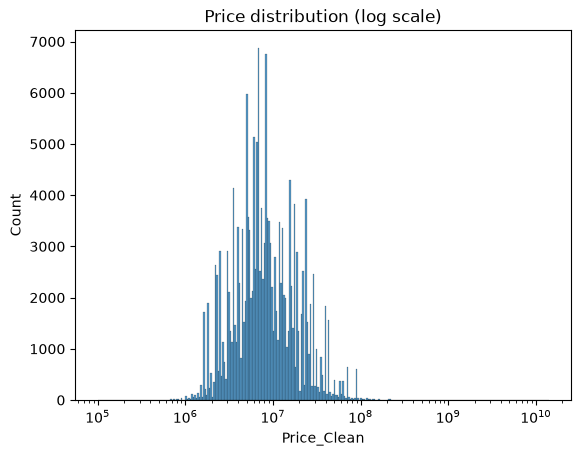

In [8]:
sns.histplot(df["Price_Clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

The price distribution is right-skewed on a linear scale, but becomes 
roughly bell-shaped (log-normal) on a log scale. Most properties are 
priced around 10^7 rupees (~1 crore), with a long tail of expensive outliers.

In [9]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        return None
    except ValueError:
        return None

df["Carpet_Area_Sqft"] = df["Carpet Area"].apply(parse_area)
df = df.dropna(subset=["Carpet_Area_Sqft"])
df.shape

(96856, 23)

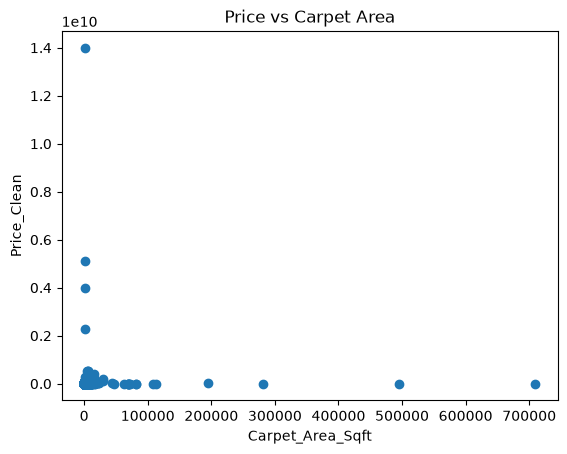

In [10]:
plt.figure()
plt.scatter(df["Carpet_Area_Sqft"], df["Price_Clean"])
plt.xlabel("Carpet_Area_Sqft")
plt.ylabel("Price_Clean")
plt.title("Price vs Carpet Area")
plt.show()

There is a clear positive relationship between carpet area and price 
larger properties tend to cost more. The spread around the trend reflects 
other factors (location, furnishing, floor) that also affect price.

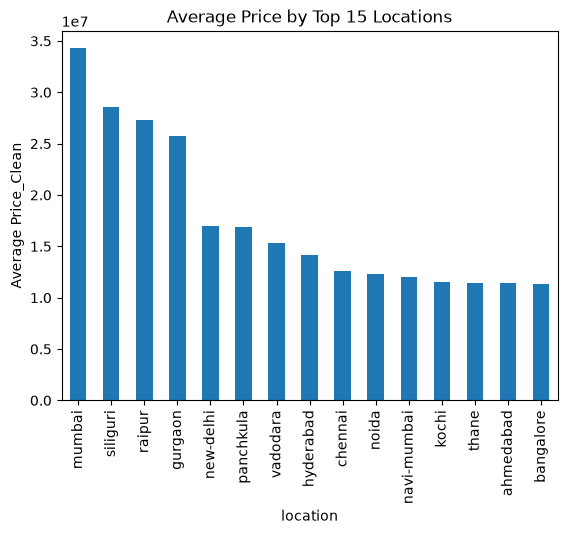

In [11]:
top_locations = df.groupby("location")["Price_Clean"].mean().sort_values(ascending=False).head(15)

plt.figure()
top_locations.plot(kind="bar")
plt.xlabel("location")
plt.ylabel("Average Price_Clean")
plt.title("Average Price by Top 15 Locations")
plt.xticks(rotation=90)
plt.show()

Mumbai has by far the highest average property price among all locations, 
consistent with its status as India's most expensive real estate market. 
Other major metro/business hub cities (Gurgaon, New Delhi) follow closely behind.

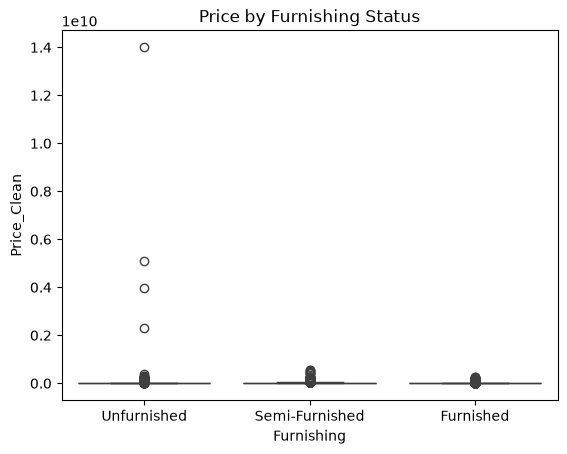

In [12]:
plt.figure()
sns.boxplot(x="Furnishing", y="Price_Clean", data=df)
plt.title("Price by Furnishing Status")
plt.show()

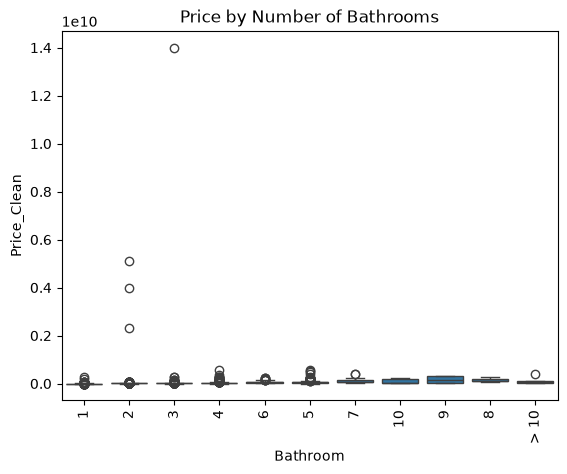

In [13]:
plt.figure()
sns.boxplot(x="Bathroom", y="Price_Clean", data=df)
plt.title("Price by Number of Bathrooms")
plt.xticks(rotation=90)
plt.show()

### Price by Furnishing & Bathroom — Observations

**Furnishing:** Furnished properties tend to have a higher median price 
than semi-furnished or unfurnished ones, though there is overlap and 
some high-price outliers in every category.

**Bathroom:** The x-axis order in this plot is currently incorrect 
(e.g. "10" appears before "2"). This happens because the `Bathroom` 
column is still stored as text (`str`), so values are sorted 
alphabetically instead of numerically. There is also at least one 
corrupted value ("10^") that isn't a valid number.

## 2.3 Cleaning & Feature Engineering 

Already done first and second points(Price is text_Areas are text)

# 3.Floor

In [14]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        floor_part = x.split("out of")[0].strip()
        if "ground" in floor_part:
            return 0
        if "basement" in floor_part:
            return -1
        if "lower" in floor_part:   # بعض الداتا فيها "Lower Basement"
            return -2
        return float(floor_part)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)

## 4.Bathroom / Balcony / Car Parking

In [15]:
def parse_bathroom(x):
    if not isinstance(x, str):
        return x
    x = x.strip()
    try:
        return float(x)
    except ValueError:
        return None

def parse_balcony(x):
    if not isinstance(x, str):
        return x
    x = x.strip()
    try:
        return float(x)
    except ValueError:
        return None

def parse_car_parking(x):
    if not isinstance(x, str):
        return x
    x = x.strip()
    try:
        return float(x)
    except ValueError:
        return None

df["Bathroom_num"] = df["Bathroom"].apply(parse_bathroom)
df["Balcony_num"] = df["Balcony"].apply(parse_balcony)
df["Car Parking_num"] = df["Car Parking"].apply(parse_car_parking)

df["Bathroom_num"] = df["Bathroom_num"].fillna(df["Bathroom_num"].median())
df["Balcony_num"] = df["Balcony_num"].fillna(0)
df["Car Parking_num"] = df["Car Parking_num"].fillna(0)

## 5.High-cardinality categoricals 

In [16]:
top_locations = df["location"].value_counts().head(50).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")

## 6.Drop useless columns

In [17]:
df = df.drop(columns=["Index", "Title", "Description", "Dimensions"])

## 7.Remove outliers

In [18]:
lower_limit = df["Price_Clean"].quantile(0.01)
upper_limit = df["Price_Clean"].quantile(0.99)
df = df[(df["Price_Clean"] >= lower_limit) & (df["Price_Clean"] <= upper_limit)]

df.shape

(95198, 24)

In [19]:
lower_limit_area = df["Carpet_Area_Sqft"].quantile(0.01)
upper_limit_area = df["Carpet_Area_Sqft"].quantile(0.99)
df = df[(df["Carpet_Area_Sqft"] >= lower_limit_area) & (df["Carpet_Area_Sqft"] <= upper_limit_area)]

df.shape

(93655, 24)

## 2.4 Build a Pipeline & Train 

## RandomForestRegressor baseline

In [21]:
numeric_features = ["Carpet_Area_Sqft", "floor_num", "Bathroom_num", "Balcony_num", "Car Parking_num"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Price_Clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([("prep", preprocessor),
                   ("reg", RandomForestRegressor(n_estimators=200, random_state=42))])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Carpet_Area_Sqft','floor_num','Bathroom_num',...,'Transaction', 'Ownership','facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

## LinearRegression baseline

In [22]:
model_lr = Pipeline([("prep", preprocessor),
                      ("reg", LinearRegression())])
model_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Carpet_Area_Sqft','floor_num','Bathroom_num',...,'Transaction', 'Ownership','facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

## 2.5 Evaluate 

In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

pred_rf = model.predict(X_test)
pred_lr = model_lr.predict(X_test)

print("RandomForest:")
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", root_mean_squared_error(y_test, pred_rf))
print("R²  :", r2_score(y_test, pred_rf))

print()
print("LinearRegression:")
print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", root_mean_squared_error(y_test, pred_lr))
print("R²  :", r2_score(y_test, pred_lr))

RandomForest:
MAE : 913117.3651000378
RMSE: 2676849.579453705
R²  : 0.9442625987202962

LinearRegression:
MAE : 3728036.340474363
RMSE: 5579870.786525085
R²  : 0.7578150980682574


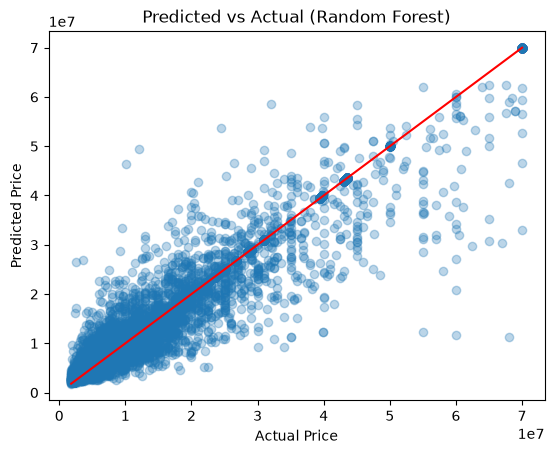

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual (Random Forest)")
plt.show()

## Model Comparison

I trained two models on the cleaned dataset: a Linear Regression baseline and a Random Forest Regressor. The Random Forest significantly outperformed Linear Regression across all three metrics (MAE, RMSE, and R²). This makes sense given the nature of the data house prices depend on complex, non-linear interactions between features like location, area, and furnishing status, which a linear model struggles to capture. Random Forest, being an ensemble of decision trees, is better suited to model these non-linear relationships and interactions between categorical and numeric features (e.g., how the effect of carpet area on price might differ depending on location).
Based on these results, I selected Random Forest Regressor as the final model for this project.

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("Cross-validation R² scores:", scores) 
print("Mean R²:", scores.mean())

Cross-validation R² scores: [ 0.63352365  0.62082525  0.68529167  0.93787526 -0.03393267]
Mean R²: 0.5687166335786596


In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mean_absolute_error(y_test, pred_lr), mean_absolute_error(y_test, pred_rf)],
    "RMSE": [root_mean_squared_error(y_test, pred_lr), root_mean_squared_error(y_test, pred_rf)],
    "R2": [r2_score(y_test, pred_lr), r2_score(y_test, pred_rf)],
}) 
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,3.728036e+06,5.579871e+06,0.757815
1,Random Forest,9.131174e+05,2.676850e+06,0.944263


## Note: 
Cross-validation scores show high variance across folds (ranging from -0.03 to 0.94), suggesting the model's performance is sensitive to how the data is split possibly due to certain folds containing harder-to-predict properties or regional price variations not well represented elsewhere in the data.

## 2.6 Export the Model 

In [29]:
import joblib

joblib.dump(model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [16771200.]


In [30]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))

In [31]:
import sklearn
print(sklearn.__version__)

1.9.0


In [36]:
model.named_steps["reg"].estimators_ = model.named_steps["reg"].estimators_[:100]
model.named_steps["reg"].n_estimators = 100

joblib.dump(model, "house_price.pkl", compress=9)

['house_price.pkl']

In [40]:
unique_locations = sorted(df["location_grouped"].unique().tolist())

with open("D:/Kareem_Hamdy/house-price-project/frontend/public/locations.json", "w") as f:
    json.dump(unique_locations, f)

print("Save Done:", len(unique_locations), "Location")

Save Done: 51 Location
